In [1]:
import fastf1
import pandas as pd
import numpy as np
import requests
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
fastf1.Cache.enable_cache("f1_cache")

In [4]:
# load 2024 Bahrain race, lap time, sector times
session_2024 = fastf1.get_session(2024, "Bahrain", "R")
session_2024.load()
laps_2024 = session_2024.laps[["Driver", "LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]].copy()
laps_2024.dropna(inplace=True)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

In [5]:
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    laps_2024[f"{col} (s)"] = laps_2024[col].dt.total_seconds()

In [6]:
# get average sector times
sector_times_2024 = laps_2024.groupby("Driver")[["Sector1Time (s)", "Sector2Time (s)", "Sector3Time (s)"]].mean().reset_index()

In [7]:
# 2025 Bahrain GP quali data
qualifying_2025 = pd.DataFrame({
    "Driver": ["VER", "NOR", "PIA", "LEC", "RUS", "HAM", "GAS", "ALO", "TSU", "SAI", "HUL", "OCO", "STR"],
    "QualifyingTime (s)": [90.423, 90.267, 89.841, 90.175, 90.009, 90.772, 90.216, 91.886, 91.303, 90.680, 92.067, 91.886, 92.283]
})

In [8]:
# add wet performance factor
driver_wet_performance = {
    "VER": 0.975196, 
    "HAM": 0.976464,  
    "LEC": 0.975862,  
    "NOR": 0.978179,  
    "ALO": 0.972655,  
    "RUS": 0.968678,  
    "SAI": 0.978754,  
    "TSU": 0.996338,  
    "OCO": 0.981810,  
    "GAS": 0.978832,  
    "STR": 0.979857   
}
qualifying_2025["WetPerformanceFactor"] = qualifying_2025["Driver"].map(driver_wet_performance)

In [ ]:
# add 2025 season points (made-up for now, replace with real values)
season_points = {
    "VER": 61,
    "NOR": 62,    
    "PIA": 80,    
    "LEC": 20,
    "RUS": 20,
    "HAM": 20,
    "GAS": 20,
    "ALO": 20,
    "TSU": 20,
    "SAI": 20,
    "HUL": 2,
    "OCO": 8,
    "STR": 11
}
qualifying_2025["SeasonPoints"] = qualifying_2025["Driver"].map(season_points)

In [10]:
API_KEY = os.getenv('OPENWEATHER_API_KEY')

if not API_KEY:
    raise ValueError("OPENWEATHER_API_KEY not found in environment variables. Please check your .env file.")

In [11]:
# weather data
weather_url = f"http://api.openweathermap.org/data/2.5/forecast?lat=26.0325&lon=50.5106&appid={API_KEY}&units=metric"
response = requests.get(weather_url)
weather_data = response.json()

forecast_time = "2025-04-30 15:00:00"
forecast_data = next((f for f in weather_data["list"] if f["dt_txt"] == forecast_time), None)

rain_probability = forecast_data["pop"] if forecast_data else 0
temperature = forecast_data["main"]["temp"] if forecast_data else 20

In [12]:
# merge sector time data
merged_data = qualifying_2025.merge(sector_times_2024, on="Driver", how="left")
merged_data["RainProbability"] = rain_probability
merged_data["Temperature"] = temperature

In [13]:
# final features including season points!
X = merged_data[[
    "QualifyingTime (s)", 
    "Sector1Time (s)", "Sector2Time (s)", "Sector3Time (s)", 
    "WetPerformanceFactor", 
    "RainProbability", 
    "Temperature",
    "SeasonPoints"
]].fillna(0)

In [14]:
# target: average lap time from 2024 race
y = merged_data.merge(
    laps_2024.groupby("Driver")["LapTime (s)"].mean(),
    left_on="Driver",
    right_index=True
)["LapTime (s)"]

In [15]:
# train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=38)
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=38)
model.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=38)

In [16]:
# predict 2025 race times
predicted_race_times = model.predict(X)
merged_data["PredictedRaceTime (s)"] = predicted_race_times
merged_data = merged_data.sort_values(by="PredictedRaceTime (s)")

In [17]:
print("\n🏁 Predicted 2025 Bahrain GP Winner 🏁\n")
print(merged_data[["Driver", "PredictedRaceTime (s)"]])


🏁 Predicted 2025 Bahrain GP Winner 🏁

   Driver  PredictedRaceTime (s)
0     VER              96.561750
3     LEC              97.252500
1     NOR              97.339857
5     HAM              97.356143
4     RUS              97.362536
9     SAI              97.428982
2     PIA              97.469661
7     ALO              97.724009
10    HUL              97.907859
12    STR              97.995429
8     TSU              98.377073
11    OCO              98.718818
6     GAS              98.725800


In [18]:
# evaluate model
y_pred = model.predict(X_test)
print(f"\n🔍 Model Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} seconds")


🔍 Model Error (MAE): 0.34 seconds


In [19]:
# Plot feature importances
feature_importance = model.feature_importances_
features = X.columns

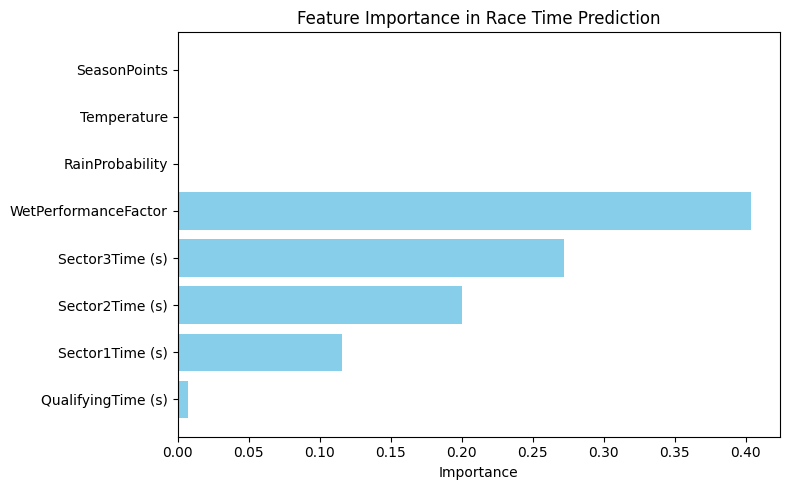

In [20]:
plt.figure(figsize=(8,5))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance in Race Time Prediction")
plt.tight_layout()
plt.show()